In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

This notebook can be run after running Katydid with the `02_trackFinding.yaml` configuration.

# Step 2 : Sequential Track Finding

The next step in reconstruction is track finding, where consecutive high power bins are grouped into a track if they satisfy different requirements. The track finding algorithm iterates through the sparse spectrogram data slice-by-slice creating "sequential line candidates" as it proceeds. After iterating through the full time-series, there are two clustering algorithms performed to patch together broken or overlapping track candidates. Finally, there is a power cut applied to the candidates to remove noise fluctuation tracks. For a more complete description of the track finding algorithm see C. Claessens' PhD Thesis section 7.3. In the configuration, this algorithm corresponds to:

```yaml
      - signal: "discrim:disc-1d"
        slot: "seq-tr-clust:disc-1d"       # Beginning track finding algorithm
      - signal: "seq-tr-clust:seq-cand"
        slot: "otc:seq-cand"
      - signal: "otc:seq-cand"
        slot: "itc:seq-cand"
      - signal: "itc:seq-cand"
        slot: "ac1b:apply"
      - signal: "ac1b:pass"
        slot: "tr-proc-ws:seq-cand"
      - signal: "egg2:egg-done"
        slot: "seq-tr-clust:done"
      - signal: "seq-tr-clust:clustering-done"
        slot: "otc:do-clustering"
      - signal: "otc:clustering-done"
        slot: "itc:do-clustering"
```

We have written the tracks to a ROOT tree, which we now plot as follows

In [2]:
treeFile = uproot.open('trackFinding_tree.root')
treeFile.classnames()

{'discPoints1D;2': 'TTree',
 'discPoints1D;1': 'TTree',
 'procTracks;2': 'TTree',
 'procTracks;1': 'TTree'}

In [3]:
processedTracksTree = treeFile['procTracks;1']
processedTracksTree.keys()

['Track',
 'Track/TObject',
 'Track/TObject/fUniqueID',
 'Track/TObject/fBits',
 'Track/fComponent',
 'Track/fAcquisitionID',
 'Track/fTrackID',
 'Track/fEventID',
 'Track/fEventSequenceID',
 'Track/fIsCut',
 'Track/fStartTimeInRunC',
 'Track/fStartTimeInAcq',
 'Track/fEndTimeInRunC',
 'Track/fTimeLength',
 'Track/fStartFrequency',
 'Track/fEndFrequency',
 'Track/fFrequencyWidth',
 'Track/fSlope',
 'Track/fIntercept',
 'Track/fTotalPower',
 'Track/fNTrackBins',
 'Track/fTotalTrackSNR',
 'Track/fMaxTrackSNR',
 'Track/fTotalTrackNUP',
 'Track/fMaxTrackNUP',
 'Track/fTotalWideTrackSNR',
 'Track/fTotalWideTrackNUP',
 'Track/fStartTimeInRunCSigma',
 'Track/fEndTimeInRunCSigma',
 'Track/fTimeLengthSigma',
 'Track/fStartFrequencySigma',
 'Track/fEndFrequencySigma',
 'Track/fFrequencyWidthSigma',
 'Track/fSlopeSigma',
 'Track/fInterceptSigma',
 'Track/fTotalPowerSigma']

In [4]:
data = {}
data['trackData'] = {}

processedTrackTreeBranches = ['Track/fAcquisitionID', 'Track/fTrackID', 'Track/fEventID', 'Track/fEventSequenceID', 'Track/fIsCut',
                              'Track/fStartTimeInRunC', 'Track/fStartTimeInAcq', 'Track/fEndTimeInRunC', 'Track/fTimeLength', 
                              'Track/fStartFrequency', 'Track/fEndFrequency', 'Track/fSlope', 'Track/fIntercept', 'Track/fTotalPower', 
                              'Track/fNTrackBins', 'Track/fTotalTrackSNR', 'Track/fMaxTrackSNR', 'Track/fTotalTrackNUP', 
                              'Track/fMaxTrackNUP']

data['trackData'] = processedTracksTree.arrays(processedTrackTreeBranches, library='np')

Text(0, 0.5, 'Frequency [Hz]')

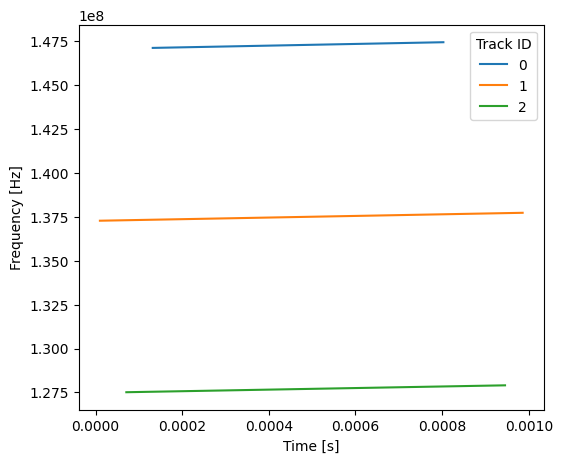

In [5]:
trackIDs = data['trackData']['Track/fTrackID']
isCut = data['trackData']['Track/fIsCut']
startTimes = data['trackData']['Track/fStartTimeInRunC']
endTimes = data['trackData']['Track/fEndTimeInRunC']
startFrequencies = data['trackData']['Track/fStartFrequency']
endFrequencies = data['trackData']['Track/fEndFrequency']
slopes = data['trackData']['Track/fSlope'] 
intercepts = data['trackData']['Track/fIntercept']

fig, ax = plt.subplots(figsize=(6,5))
for id in trackIDs:
    trackTimes = np.linspace(startTimes[id], endTimes[id], 100)
    trackFreqs = slopes[id]*trackTimes + intercepts[id]
    ax.plot(trackTimes, trackFreqs, label=id)

ax.legend(title='Track ID')
# ax.set_xlim([0,3.1e-3])
# ax.set_ylim([80.e6,200.e6])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Frequency [Hz]')

Three tracks where found, as we expect by inspecting the sparse spectrogram in the previous `01_bkgSubtractedSpec.yaml` analysis. To compare with the sparse spectrogram, we can overlay these tracks

In [6]:
treeFile = uproot.open('trackFinding_tree.root')
sparseSpecTree = treeFile['discPoints1D;1']
sparseSpecTreeBranches = ['TimeInRunC', 'Abscissa', 'Threshold']

data['sparseSpecData'] = {}
data['sparseSpecData'] = sparseSpecTree.arrays(sparseSpecTreeBranches, library='np')

sparseSpecTimes = data['sparseSpecData']['TimeInRunC']
sparseSpecFreqs = data['sparseSpecData']['Abscissa']
sparseSpecThreshold = data['sparseSpecData']['Threshold']

Text(0, 0.5, 'Frequency [Hz]')

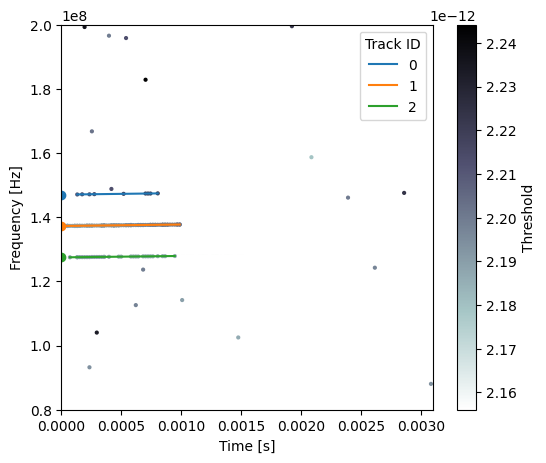

In [7]:
fig, ax = plt.subplots(figsize=(6,5))
sparseSpecPlot = ax.scatter(sparseSpecTimes, sparseSpecFreqs, c=sparseSpecThreshold, cmap='bone_r', s=4)
fig.colorbar(sparseSpecPlot, label='Threshold')

for id in trackIDs:
    trackTimes = np.linspace(startTimes[id], endTimes[id], 100)
    trackFreqs = slopes[id]*trackTimes + intercepts[id]
    ax.plot(trackTimes, trackFreqs, label=id)
    ax.scatter(0, intercepts[id], label='')

ax.legend(title='Track ID')
ax.set_xlim([0,3.1e-3])
ax.set_ylim([80.e6,200.e6])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Frequency [Hz]')

Note, the algorithm outputs a track slope and intercept, which are used for a better reconstruction of the start frequency. We can use the intercept to reconstruct an axial frequency, we will develop a processor in Katydid to perform this reconstruction!